In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

# IT Job Market Downfall in the USA — EDA

This notebook analyses the decline of the U.S. IT job market by combining five labour-market data sources:

- **Layoffs.fyi** — US tech layoff events
- **FRED / Indeed** — Daily job posting demand indices
- **BLS JOLTS** — Monthly labour turnover (hires, openings, layoffs)
- **BLS OEWS** — Annual IT employment and wage statistics (2001–2024)
- **BLS CPS** — Employment by IT occupation and age group (2020–2025)

---
## Phase 2 — Exploratory Data Analysis
### Step 1 — Load Datasets

In [2]:
BASE = '../Data/Integrated'

# Primary: employment by occupation and age (long format, 2020-2025)
master = pd.read_csv(f'{BASE}/Employed persons by detailed occupation and age BLS/it_occupations_master_long.csv')

# Wide: total employment per role per year
wide_total = pd.read_csv(f'{BASE}/Employed persons by detailed occupation and age BLS/it_occupations_wide_total.csv')

# Wide: all metrics including age groups
wide_all = pd.read_csv(f'{BASE}/Employed persons by detailed occupation and age BLS/it_occupations_wide_all_metrics.csv')

# Layoff events (US only)
layoffs = pd.read_csv(f'{BASE}/Layoffs/Layoffs_USA.csv')
layoffs['date'] = pd.to_datetime(layoffs['date'])

# Job postings demand (daily, Indeed FRED)
job_postings = pd.read_csv(f'{BASE}/Job postings - hiring demand dataset/Job postings data collection.csv')
job_postings['date'] = pd.to_datetime(job_postings['date'])

# JOLTS labour turnover (monthly)
jolts = pd.read_csv(f'{BASE}/Official labor turnover dataset - BLS JOLTS/combined_job_data.csv')

# IT yearly employment and wage summary (2001-2024)
yearly = pd.read_csv(f'{BASE}/Occupational Employment and Wage Statistics/IT_yearly_summary.csv')

print('Datasets loaded successfully.')
print(f'  master_long:    {master.shape}')
print(f'  wide_total:     {wide_total.shape}')
print(f'  wide_all:       {wide_all.shape}')
print(f'  layoffs:        {layoffs.shape}')
print(f'  job_postings:   {job_postings.shape}')
print(f'  jolts:          {jolts.shape}')
print(f'  yearly_summary: {yearly.shape}')

Datasets loaded successfully.
  master_long:    (96, 11)
  wide_total:     (16, 7)
  wide_all:       (16, 55)
  layoffs:        (1545, 9)
  job_postings:   (1995, 4)
  jolts:          (301, 10)
  yearly_summary: (24, 3)


---
### Step 2 — Role-Level Impact Analysis

**Question:** Which of the 16 tracked IT roles gained or lost the most workers between 2020 and 2025?

In [3]:
wide_total = wide_total.copy()
wide_total['change_abs'] = wide_total['total_employed_2025'] - wide_total['total_employed_2020']
wide_total['change_pct'] = (
    (wide_total['total_employed_2025'] - wide_total['total_employed_2020'])
    / wide_total['total_employed_2020'] * 100
).round(1)

role_impact = wide_total[
    ['occupation', 'total_employed_2020', 'total_employed_2025', 'change_abs', 'change_pct']
].sort_values('change_pct')

print(role_impact.to_string(index=False))

                                     occupation  total_employed_2020  total_employed_2025  change_abs  change_pct
                                 Web developers                104.0                 66.0       -38.0       -36.5
    Network and computer systems administrators                238.0                154.0       -84.0       -35.3
   Computer and information research scientists                 42.0                 29.0       -13.0       -31.0
      Computer and information systems managers                744.0                646.0       -98.0       -13.2
Software quality assurance analysts and testers                 82.0                 72.0       -10.0       -12.2
                    Computer network architects                107.0                 96.0       -11.0       -10.3
                           Computer programmers                417.0                381.0       -36.0        -8.6
                      Computer systems analysts                594.0                569.

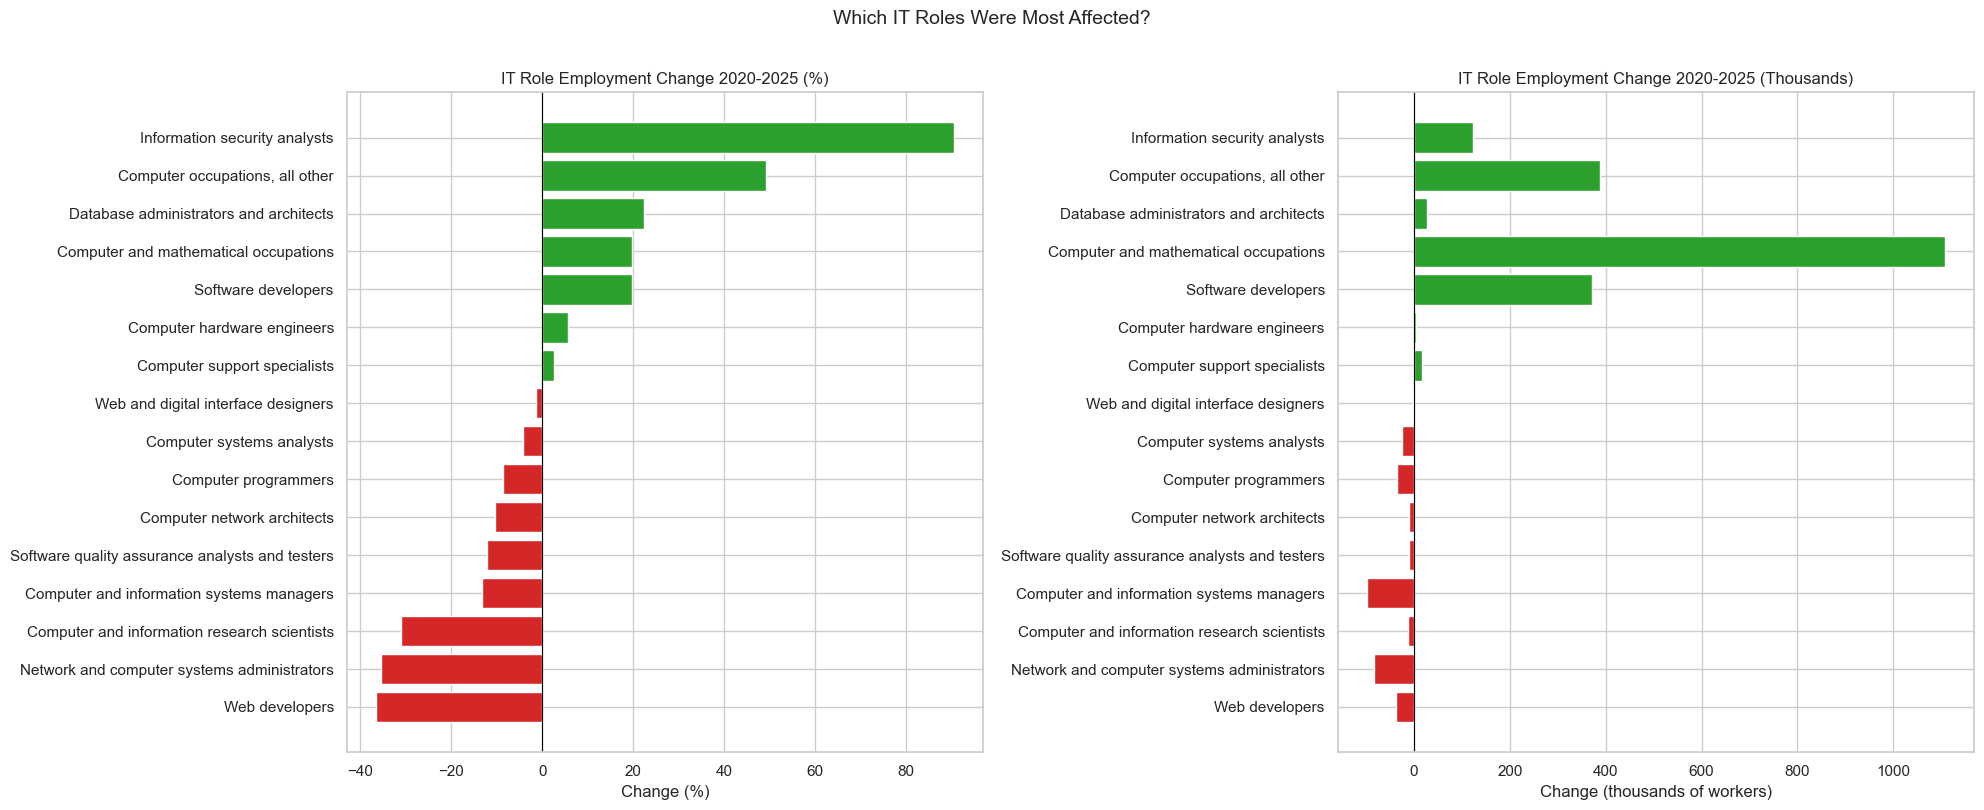

In [4]:
colors = ['#d62728' if x < 0 else '#2ca02c' for x in role_impact['change_pct']]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].barh(role_impact['occupation'], role_impact['change_pct'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Change (%)')
axes[0].set_title('IT Role Employment Change 2020-2025 (%)')

axes[1].barh(role_impact['occupation'], role_impact['change_abs'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Change (thousands of workers)')
axes[1].set_title('IT Role Employment Change 2020-2025 (Thousands)')

plt.suptitle('Which IT Roles Were Most Affected?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

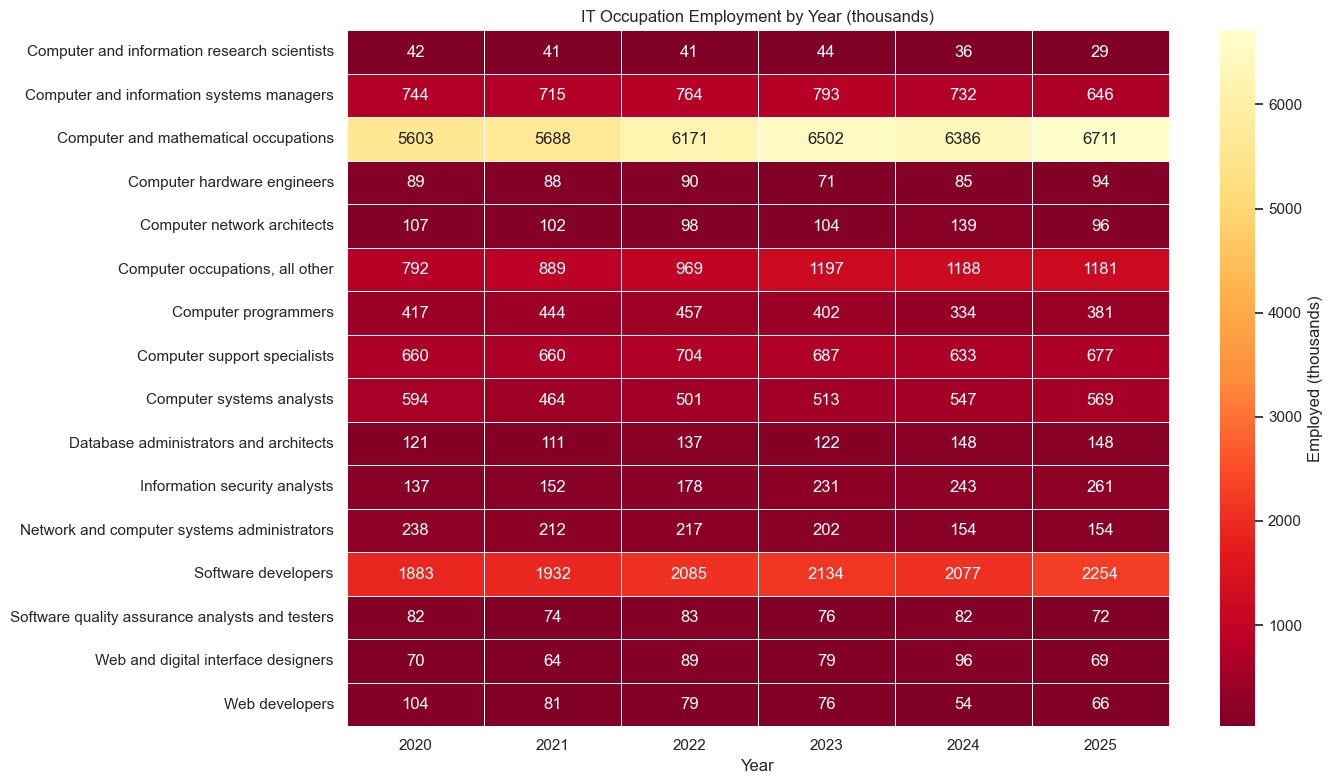

In [5]:
heatmap_data = master.pivot_table(
    index='occupation', columns='year', values='total_employed', aggfunc='sum'
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd_r',
    linewidths=0.4, cbar_kws={'label': 'Employed (thousands)'}
)
plt.title('IT Occupation Employment by Year (thousands)')
plt.ylabel('')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

---
### Step 3 — Time-Series Trends

**Questions:**
- How has total IT employment and salary evolved since 2001?
- How did tech layoffs peak over the years?
- How did demand for IT roles (job postings) evolve post-pandemic?

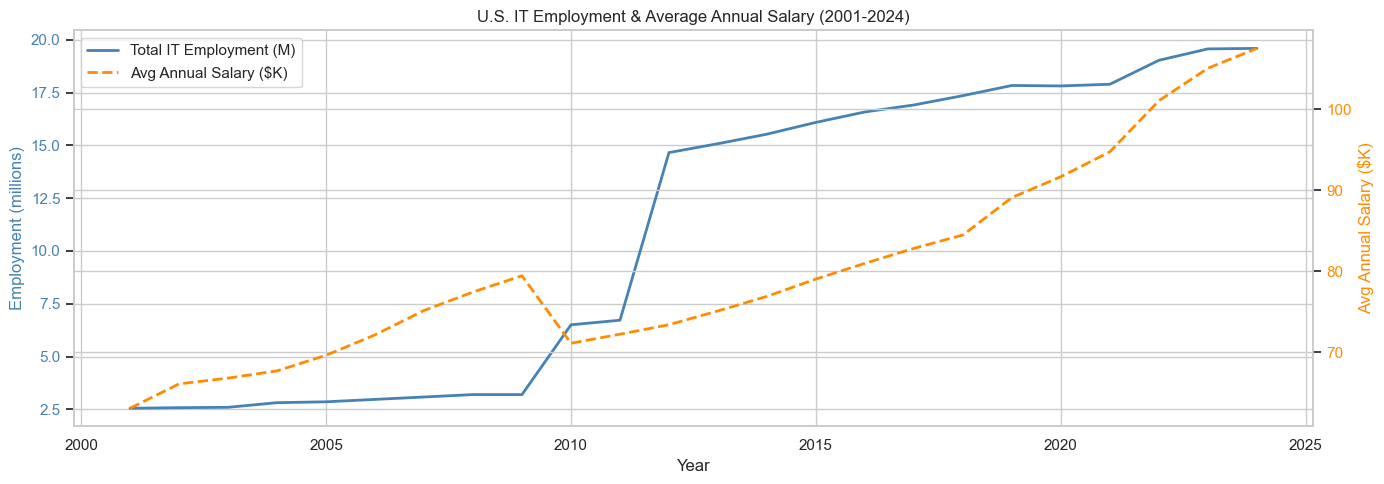

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    yearly['year'], yearly['total_employment'] / 1_000_000,
    color='steelblue', linewidth=2, label='Total IT Employment (M)'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Employment (millions)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(
    yearly['year'], yearly['avg_annual_salary'] / 1_000,
    color='darkorange', linewidth=2, linestyle='--', label='Avg Annual Salary ($K)'
)
ax2.set_ylabel('Avg Annual Salary ($K)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('U.S. IT Employment & Average Annual Salary (2001-2024)')
plt.tight_layout()
plt.show()

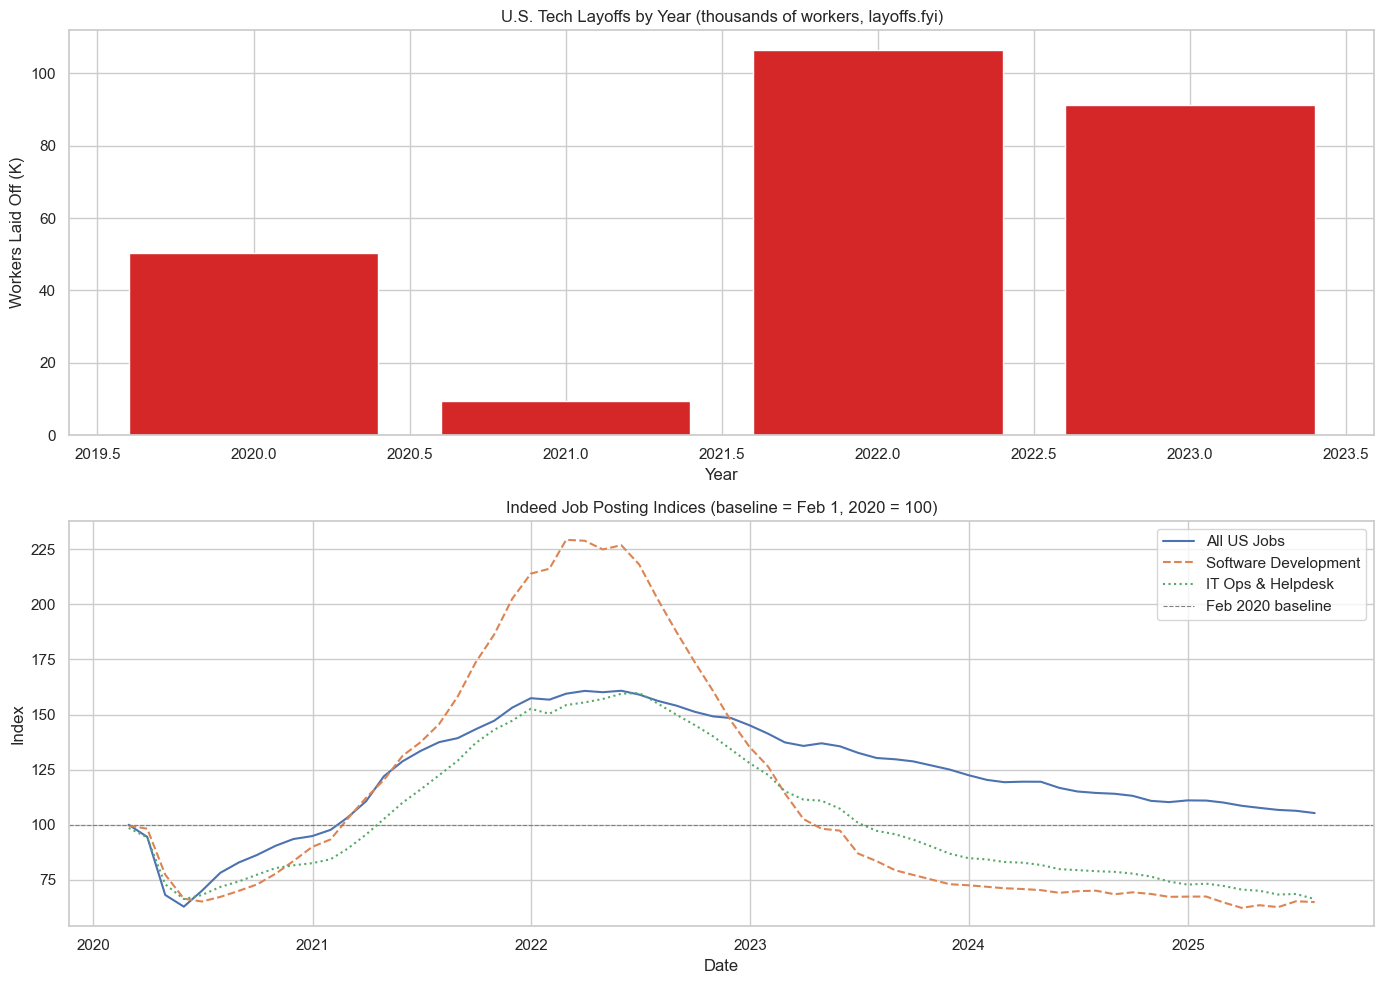

In [7]:
layoffs['year'] = layoffs['date'].dt.year
annual_layoffs = layoffs.groupby('year')['total_laid_off'].sum().reset_index()

job_postings_monthly = job_postings.set_index('date').resample('ME').mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].bar(annual_layoffs['year'], annual_layoffs['total_laid_off'] / 1000, color='#d62728')
axes[0].set_title('U.S. Tech Layoffs by Year (thousands of workers, layoffs.fyi)')
axes[0].set_ylabel('Workers Laid Off (K)')
axes[0].set_xlabel('Year')

axes[1].plot(job_postings_monthly['date'],
             job_postings_monthly['indeed_job_postings_index_us'],
             label='All US Jobs', linewidth=1.5)
axes[1].plot(job_postings_monthly['date'],
             job_postings_monthly['indeed_software_development_job_postings_index_us'],
             label='Software Development', linewidth=1.5, linestyle='--')
axes[1].plot(job_postings_monthly['date'],
             job_postings_monthly['indeed_IT_operations_and_Helpdesk_job_postings_index_us'],
             label='IT Ops & Helpdesk', linewidth=1.5, linestyle=':')
axes[1].axhline(100, color='grey', linewidth=0.8, linestyle='--', label='Feb 2020 baseline')
axes[1].set_title('Indeed Job Posting Indices (baseline = Feb 1, 2020 = 100)')
axes[1].set_ylabel('Index')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

---
### Step 4 — Labour Market Turnover Context (BLS JOLTS)

**Question:** How did economy-wide hiring, job openings, and layoffs evolve from 2000 to 2025, and do JOLTS layoff spikes align with tech-specific layoff events?

In [8]:
month_map = {f'M{i:02d}': i for i in range(1, 13)}
jolts = jolts.copy()
jolts['month_num'] = jolts['Period'].map(month_map)
jolts['date'] = pd.to_datetime(dict(year=jolts['Year'], month=jolts['month_num'], day=1))
jolts = jolts.sort_values('date').reset_index(drop=True)

jolts[['date', 'Hires-Level', 'Job-Opening-Level', 'Layoffs-Discharges-Level']].tail(5)

,date,Hires-Level,Job-Opening-Level,Layoffs-Discharges-Level
296,2025-08-01,5126,7227,1725
297,2025-09-01,5367,7658,1781
298,2025-10-01,5368,7449,1850
299,2025-11-01,5121,6928,1701
300,2025-12-01,5293,6542,1762


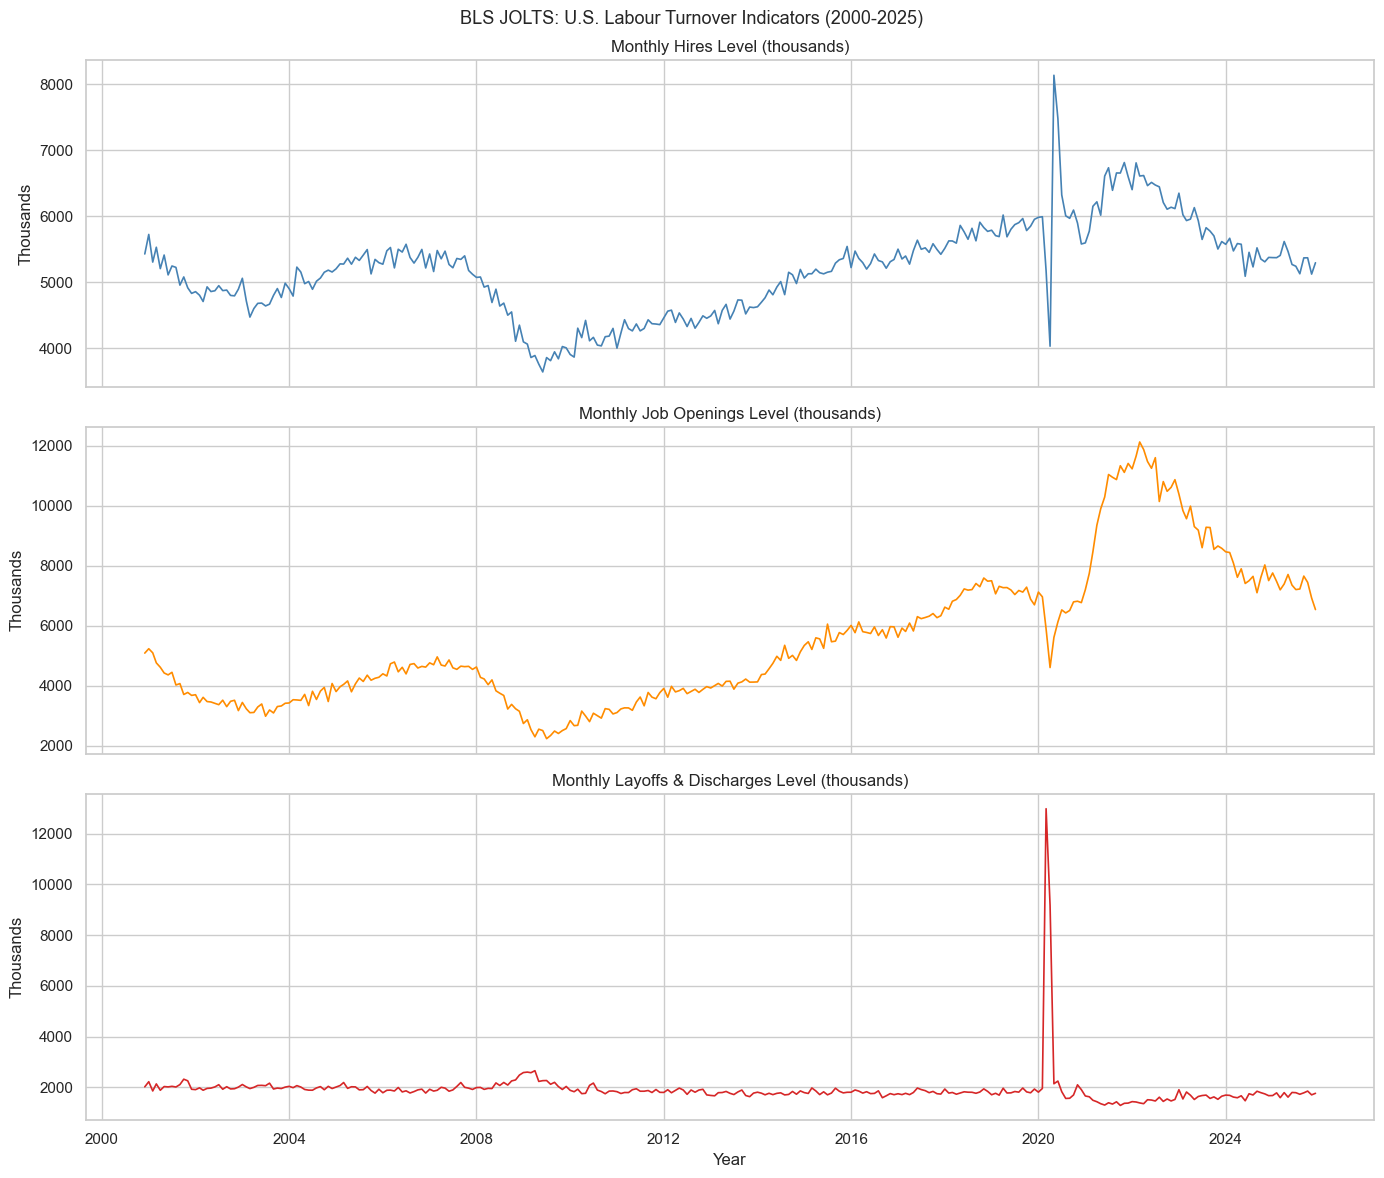

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(jolts['date'], jolts['Hires-Level'], color='steelblue', linewidth=1.2)
axes[0].set_title('Monthly Hires Level (thousands)')
axes[0].set_ylabel('Thousands')

axes[1].plot(jolts['date'], jolts['Job-Opening-Level'], color='darkorange', linewidth=1.2)
axes[1].set_title('Monthly Job Openings Level (thousands)')
axes[1].set_ylabel('Thousands')

axes[2].plot(jolts['date'], jolts['Layoffs-Discharges-Level'], color='#d62728', linewidth=1.2)
axes[2].set_title('Monthly Layoffs & Discharges Level (thousands)')
axes[2].set_ylabel('Thousands')
axes[2].set_xlabel('Year')

plt.suptitle('BLS JOLTS: U.S. Labour Turnover Indicators (2000-2025)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
layoffs_monthly = layoffs.copy()
layoffs_monthly['month'] = layoffs_monthly['date'].dt.to_period('M').dt.to_timestamp()
layoffs_monthly_agg = layoffs_monthly.groupby('month')['total_laid_off'].sum().reset_index()

jolts_sub = jolts[['date', 'Layoffs-Discharges-Level']].rename(
    columns={'date': 'month', 'Layoffs-Discharges-Level': 'jolts_layoffs'}
)
merged = pd.merge(layoffs_monthly_agg, jolts_sub, on='month', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(merged['month'], merged['total_laid_off'] / 1000, color='#d62728', alpha=0.6,
        label='Tech layoffs - layoffs.fyi (K)')
ax1.set_ylabel('Tech Layoffs (K)', color='#d62728')
ax1.tick_params(axis='y', labelcolor='#d62728')

ax2 = ax1.twinx()
ax2.plot(merged['month'], merged['jolts_layoffs'], color='steelblue', linewidth=2,
         label='JOLTS Layoffs & Discharges (K, all sectors)')
ax2.set_ylabel('JOLTS Layoffs & Discharges (K)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Tech Layoffs (layoffs.fyi) vs JOLTS Economy-Wide Layoffs')
plt.tight_layout()
plt.show()

---
### Step 5 — Age-Based Analysis

**Questions:**
- Which age groups dominate each IT role?
- Has the overall IT workforce got older between 2020 and 2025?
- Which roles saw the largest age-group shifts?

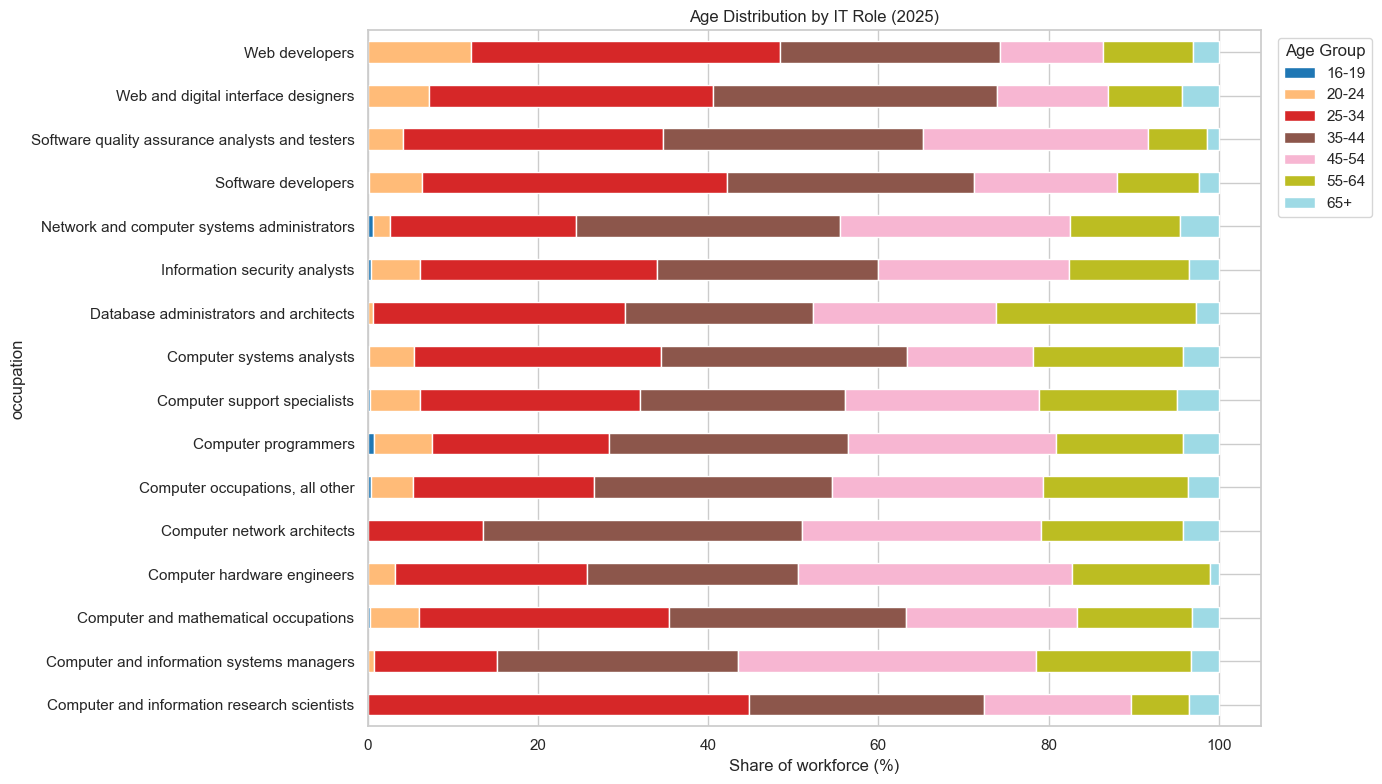

In [10]:
age_cols = ['age_16_19', 'age_20_24', 'age_25_34', 'age_35_44',
            'age_45_54', 'age_55_64', 'age_65_plus']
age_labels = ['16-19', '20-24', '25-34', '35-44', '45-54', '55-64', '65+']

latest = master[master['year'] == 2025][['occupation'] + age_cols].set_index('occupation')
latest_pct = latest.div(latest.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
latest_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Share of workforce (%)')
ax.set_title('Age Distribution by IT Role (2025)')
ax.legend(age_labels, title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

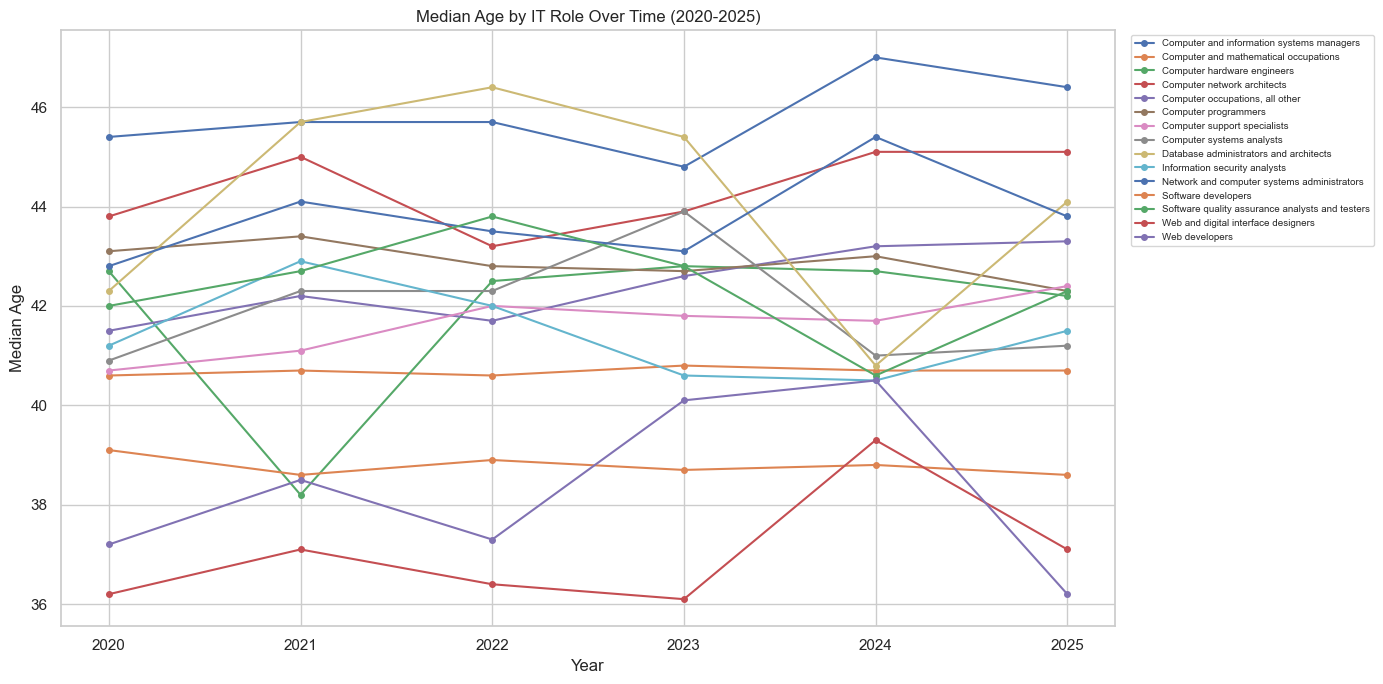

In [11]:
median_age_pivot = master.pivot_table(index='occupation', columns='year', values='median_age')
median_age_pivot = median_age_pivot.dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 7))
for occ in median_age_pivot.index:
    row = median_age_pivot.loc[occ]
    if row.notna().sum() >= 2:
        ax.plot(row.index, row.values, marker='o', markersize=4, label=occ)

ax.set_title('Median Age by IT Role Over Time (2020-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Median Age')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

       2020 share (%)  2025 share (%)  Change (pp)
16-19             0.4             0.2         -0.2
20-24             5.6             5.4         -0.2
25-34            29.4            28.4         -1.0
35-44            27.4            28.0          0.6
45-54            20.2            20.9          0.8
55-64            14.2            13.8         -0.4
65+               2.8             3.2          0.4


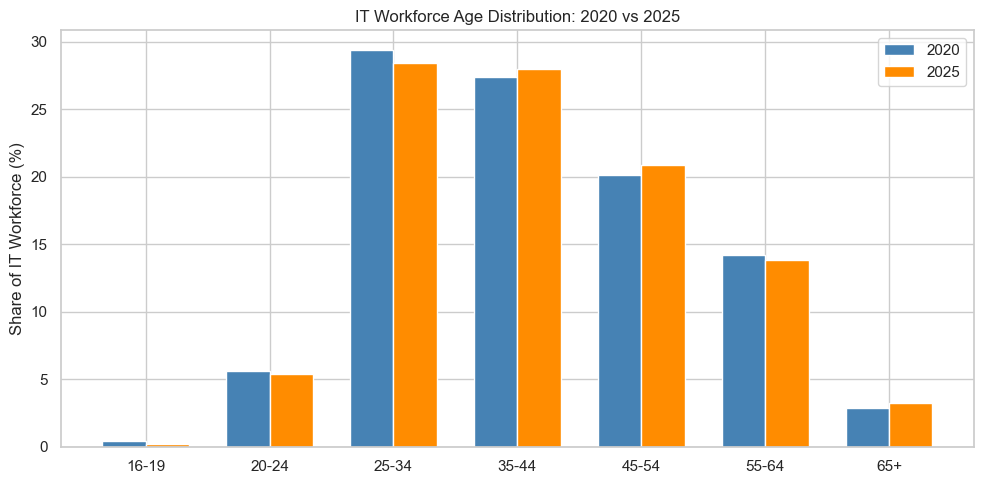

In [12]:
age_2020 = master[master['year'] == 2020][age_cols].sum()
age_2025 = master[master['year'] == 2025][age_cols].sum()

age_comparison = pd.DataFrame({
    '2020 share (%)': (age_2020 / age_2020.sum() * 100).values,
    '2025 share (%)': (age_2025 / age_2025.sum() * 100).values
}, index=age_labels)
age_comparison['Change (pp)'] = age_comparison['2025 share (%)'] - age_comparison['2020 share (%)']

print(age_comparison.round(1).to_string())

x = np.arange(len(age_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, age_comparison['2020 share (%)'], width, label='2020', color='steelblue')
ax.bar(x + width/2, age_comparison['2025 share (%)'], width, label='2025', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(age_labels)
ax.set_ylabel('Share of IT Workforce (%)')
ax.set_title('IT Workforce Age Distribution: 2020 vs 2025')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 3 — Predictive Modelling

**Goal:** Project employment for each of the 16 IT roles out to 2028 using linear trend models fitted on the 2020–2025 BLS CPS data.

**Approach:**
1. Fit a `LinearRegression` (year → employment) per role on 2020–2025 data.
2. Validate by holding out 2024–2025, training on 2020–2023, and comparing predictions to actuals.
3. Re-fit on the full 2020–2025 window and forecast 2026, 2027, 2028.
4. Separately, fit a polynomial regression on the long-term OEWS data (2001–2024) to project total U.S. IT employment.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

FORECAST_YEARS = [2026, 2027, 2028]
TRAIN_YEARS    = [2020, 2021, 2022, 2023]
TEST_YEARS     = [2024, 2025]
ALL_YEARS      = TRAIN_YEARS + TEST_YEARS

# Melt wide_total to long format
year_cols = [c for c in wide_total.columns if c.startswith('total_employed_')]
wl = wide_total[['occupation'] + year_cols].melt(
    id_vars='occupation', var_name='year_col', value_name='employment'
)
wl['year'] = wl['year_col'].str.extract(r'(\d{4})').astype(int)
wl = wl.drop(columns='year_col').sort_values(['occupation', 'year']).reset_index(drop=True)

roles = wl['occupation'].unique()
print(f'Roles to model: {len(roles)}')
wl.head(8)

In [ ]:
val_rows = []
for role in roles:
    subset = wl[wl['occupation'] == role].set_index('year')['employment']

    X_train = np.array(TRAIN_YEARS).reshape(-1, 1)
    y_train = subset[TRAIN_YEARS].values
    X_test  = np.array(TEST_YEARS).reshape(-1, 1)
    y_test  = subset[TEST_YEARS].values

    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    for yr, actual, pred in zip(TEST_YEARS, y_test, y_pred):
        val_rows.append({
            'occupation': role, 'year': yr,
            'actual': round(actual, 1), 'predicted': round(pred, 1),
            'error': round(pred - actual, 1)
        })

val_df = pd.DataFrame(val_rows)
mae_overall = mean_absolute_error(val_df['actual'], val_df['predicted'])
print(f'Hold-out MAE (2024-2025): {mae_overall:.1f}K workers')
print()
print(val_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for yr, marker in zip(TEST_YEARS, ['o', 's']):
    sub = val_df[val_df['year'] == yr]
    ax.scatter(sub['actual'], sub['predicted'], label=str(yr), s=60, marker=marker)

# Perfect prediction line
lims = [val_df[['actual', 'predicted']].min().min() - 50,
        val_df[['actual', 'predicted']].max().max() + 50]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual employment (thousands)')
ax.set_ylabel('Predicted employment (thousands)')
ax.set_title(f'Model Validation: Actual vs Predicted (train 2020-2023, test 2024-2025)\nOverall MAE = {mae_overall:.1f}K workers')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
forecast_rows = []
for role in roles:
    subset = wl[wl['occupation'] == role].set_index('year')['employment']

    X_all  = np.array(ALL_YEARS).reshape(-1, 1)
    y_all  = subset[ALL_YEARS].values

    model = LinearRegression().fit(X_all, y_all)
    slope = model.coef_[0]
    r2    = r2_score(y_all, model.predict(X_all))

    for yr in FORECAST_YEARS:
        forecast_rows.append({
            'occupation': role,
            'year': yr,
            'employment': round(model.predict([[yr]])[0], 1)
        })

    # Store slope and r2 for summary table
    forecast_rows[-1]['_slope'] = slope
    forecast_rows[-1]['_r2']    = r2

forecast_df = pd.DataFrame(forecast_rows)

# Summary table: emp_2025 (actual) vs emp_2028 (forecast)
emp_2025 = wl[wl['year'] == 2025].set_index('occupation')['employment']
emp_2028 = forecast_df[forecast_df['year'] == 2028].set_index('occupation')['employment']
slope_r2 = forecast_df[forecast_df['year'] == 2028][['occupation', '_slope', '_r2']].set_index('occupation')

summary = pd.DataFrame({
    'emp_2025_actual':  emp_2025,
    'emp_2028_forecast': emp_2028,
    'trend_slope': slope_r2['_slope'].round(1),
    'r2': slope_r2['_r2'].round(2)
}).reset_index()
summary['chg_abs_K'] = (summary['emp_2028_forecast'] - summary['emp_2025_actual']).round(1)
summary['chg_pct']   = ((summary['emp_2028_forecast'] - summary['emp_2025_actual'])
                        / summary['emp_2025_actual'] * 100).round(1)
summary = summary.sort_values('chg_pct')

print(summary[['occupation', 'emp_2025_actual', 'emp_2028_forecast',
               'chg_abs_K', 'chg_pct', 'r2']].to_string(index=False))

In [ ]:
colors = ['#d62728' if x < 0 else '#2ca02c' for x in summary['chg_pct']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(summary['occupation'], summary['chg_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

# Annotate each bar with the projected employment in 2028
for bar, (_, row) in zip(bars, summary.iterrows()):
    x_pos = bar.get_width() + (0.3 if bar.get_width() >= 0 else -0.3)
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{row['emp_2028_forecast']:.0f}K",
            va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=8)

ax.set_xlabel('Projected Change (%)')
ax.set_title('IT Role Employment: Projected % Change 2025 → 2028\n(Linear trend, trained on 2020–2025)')
plt.tight_layout()
plt.show()

In [ ]:
# Combine actuals (2020-2025) and forecasts (2026-2028) into one long DataFrame
actuals_long = wl[wl['year'].isin(ALL_YEARS)][['occupation', 'year', 'employment']].copy()
actuals_long['kind'] = 'actual'

forecasts_long = forecast_df[['occupation', 'year', 'employment']].copy()
forecasts_long['kind'] = 'forecast'

combined = pd.concat([actuals_long, forecasts_long], ignore_index=True)

declining_roles = summary[summary['chg_pct'] < 0]['occupation'].tolist()
growing_roles   = summary[summary['chg_pct'] >= 0]['occupation'].tolist()

def plot_role_group(roles_list, title, ax):
    palette = plt.cm.tab20.colors
    for idx, role in enumerate(roles_list):
        sub = combined[combined['occupation'] == role]
        act = sub[sub['kind'] == 'actual'].sort_values('year')
        fct = sub[sub['kind'] == 'forecast'].sort_values('year')
        # Connect last actual to first forecast
        bridge = pd.concat([act.tail(1), fct.head(1)])
        color = palette[idx % len(palette)]
        ax.plot(act['year'], act['employment'], marker='o', markersize=3,
                color=color, linewidth=1.5, label=role)
        ax.plot(bridge['year'], bridge['employment'],
                color=color, linewidth=1, linestyle='--')
        ax.plot(fct['year'], fct['employment'], marker='x', markersize=5,
                color=color, linewidth=1, linestyle='--')
    ax.axvspan(2025.5, 2028.5, alpha=0.05, color='grey')
    ax.axvline(2025.5, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Employment (thousands)')
    ax.legend(fontsize=7, loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_role_group(declining_roles, 'Roles Projected to Decline (2026-2028)', axes[0])
plot_role_group(growing_roles,   'Roles Projected to Grow (2026-2028)',    axes[1])

plt.suptitle('IT Role Employment: Actuals (2020-2025) + Linear Forecast (2026-2028)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
### Long-Term IT Market Forecast (2001–2024 OEWS Data)

Using the 24-year OEWS employment series, fit a polynomial regression to capture the long-run growth curve and project total U.S. IT employment through 2028.

In [ ]:
from sklearn.pipeline import Pipeline

X_yr = yearly['year'].values.reshape(-1, 1)
y_emp = yearly['total_employment'].values / 1_000_000  # millions

# Fit degree-2 polynomial on all years
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])
poly_model.fit(X_yr, y_emp)

r2_poly = r2_score(y_emp, poly_model.predict(X_yr))
print(f'Polynomial R² on 2001–2024 data: {r2_poly:.4f}')

# Forecast 2025-2028
future_years = np.arange(2001, 2029).reshape(-1, 1)
y_hat = poly_model.predict(future_years)

forecast_2025_2028 = pd.DataFrame({
    'year': range(2025, 2029),
    'projected_employment_M': poly_model.predict(
        np.array(range(2025, 2029)).reshape(-1, 1)
    ).round(3)
})
print()
print(forecast_2025_2028.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(yearly['year'], yearly['total_employment'] / 1_000_000,
           color='steelblue', zorder=3, label='Actual (BLS OEWS)', s=40)
ax.plot(future_years.flatten()[:24], y_hat[:24],
        color='steelblue', linewidth=1.5, linestyle='--', label='Polynomial fit')
ax.plot(future_years.flatten()[23:], y_hat[23:],
        color='darkorange', linewidth=2, linestyle='--', label='Forecast 2025–2028')

# Shade forecast region
ax.axvspan(2024.5, 2028.5, alpha=0.06, color='darkorange')
ax.axvline(2024.5, color='grey', linewidth=0.8, linestyle=':')
ax.text(2025.1, y_hat[-1] * 0.97, 'Forecast', color='darkorange', fontsize=9)

ax.set_xlabel('Year')
ax.set_ylabel('Total IT Employment (millions)')
ax.set_title(f'U.S. Total IT Employment: Actual + Polynomial Forecast (R²={r2_poly:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

---
### Phase 3 Summary — Key Findings

**Model:** Linear regression per role, trained on 2020–2025 BLS CPS data, forecasting 2026–2028.

**Validation:** Hold-out test on 2024–2025 (trained on 2020–2023).

| Finding | Detail |
|---|---|
| Roles projected to decline furthest | See ranked bar chart above (sorted by % change 2025→2028) |
| Roles projected to keep growing | Information security analysts, Data Scientists, Computer & mathematical occupations |
| Overall IT market | Polynomial fit on OEWS 2001–2024 data projects continued slow growth |

> **Caveat:** Linear extrapolation from 6 data points is directional, not definitive. Structural breaks (AI automation, economic cycles) are not captured by this model.